In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as inter
from scipy import odr as mmq
import pandas as pd

/tmp/ipykernel_38837/715080414.py:4: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy import odr as mmq


# Experimento 2 - Atividade 3: Movimento de elétrons sob ação de campos magnéticos

In [2]:
# 1. Constantes Físicas
e = 1.602176634e-19 # Carga elementar do elétron (C)
m = 9.10938356e-31 # Massa do elétron (kg)

# 2. Parâmetros do Experimento
V_AC = 120.0 # Tensão de aceleração (V)
L = 0.40 # Comprimento do tubo de aceleração (m)

In [3]:
# 3. Leitura dos dados experimentais
arquivo_campo_baixo = "campo_magnetico_baixo.csv"

try:
    df_exp_campo_baixo = pd.read_csv(arquivo_campo_baixo)

    # Validação dos dados do campo
    colunas_campo = ["Posição (cm)", "Incerteza da Posição (cm)", "Campo Magnético X (µT)", "Incerteza do Campo X (µT)", "Campo Magnético Y (µT)", "Incerteza do Campo Y (µT)", "Campo Magnético Z (µT)", "Incerteza do Campo Z (µT)"]
    for c in colunas_campo:
        if c not in df_exp_campo_baixo:
            raise ValueError(f"Coluna '{c}' não encontrada!")
    
    # Extração dos dados do campo
    posicao_cm = df_exp_campo_baixo["Posição (cm)"].values.astype(float).tolist()
    incerteza_posicao_cm = df_exp_campo_baixo["Incerteza da Posição (cm)"].values.astype(float).tolist()
    campo_x = df_exp_campo_baixo["Campo Magnético X (µT)"].values.astype(float).tolist()
    incerteza_campo_x = df_exp_campo_baixo["Incerteza do Campo X (µT)"].values.astype(float).tolist()

except FileNotFoundError:
    print(f"Arquivo '{arquivo_campo_baixo}' não encontrado!")
except Exception as e:
    print(f"Erro ao ler '{arquivo_campo_baixo}': {e}")

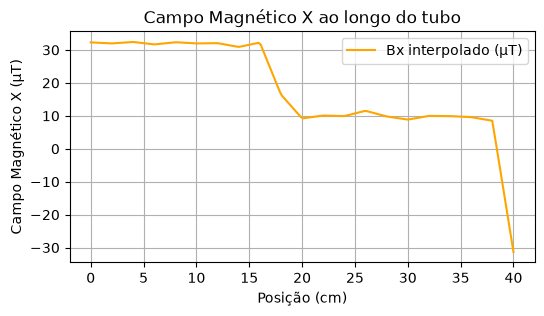

In [4]:
# 3. Criando a função de interpolação do campo magnético
obter_Bx = inter.interp1d(posicao_cm, campo_x, kind='linear', fill_value="extrapolate")

# Teste da função de interpolação
y_teste = np.linspace(0, L * 100, 200) # Posições ao longo do tubo
plt.figure(figsize=(6, 3))
plt.plot(y_teste, obter_Bx(y_teste), color='orange', label='Bx interpolado (µT)')
plt.xlabel('Posição (cm)')
plt.ylabel('Campo Magnético X (µT)')
plt.title('Campo Magnético X ao longo do tubo')
plt.grid(True)
plt.legend()
plt.show()

In [5]:
# 4. Condições iniciais do elétron
y = 0.0 # Posição inicial (m)
z = 0.0 # Posição inicial (m)

# Logo após a aceleração, há apenas componente da velocidade em y
vy = np.sqrt(2 * e * V_AC / m) # Velocidade inicial em y (m/s)
vz = 0.0 # Velocidade inicial em z (m/s)

# 5. Configuração do Passo de Tempo (dt)
# Como o elétron viaja extremamente rápido, o dt precisa ser minúsculo (da ordem de picosegundos)
tempo_estimado_voo = L / vy # Tempo total de voo (s)
dt = tempo_estimado_voo / 10000 # Dividindo a trajetória em 10000 pequenos trechos de tempo

# Listas para armazenar o histórico da trajetória e plotar o gráfico depois
historico_y = [y]
historico_z = [z]
histórico_t = [0.0]
t = 0.0

# 6. Laço de Simulação (Método de Euler-Cromer)
while y < L:
    # Obtém o campo Bx correspondente à posição y atual do elétron
    Bx = obter_Bx(y)

    # Equações de movimento deduzidas da Força de Lorentz (F = -e * v x B)
    # Devido ao campo Bx, surge aceleração az (pela velocidade vy) e ay (pela velocidade vz)
    ay = - (e / m) * vz * Bx
    az = (e / m) * vy * Bx

    # Atualiza as velocidades (Método de Euler-Cromer)
    vy += ay * dt
    vz += az * dt

    # Atualiza as posições
    y += vy * dt
    z += vz * dt

    # Atualiza o tempo
    t += dt

    # Armazena o histórico da trajetória
    historico_y.append(y)
    historico_z.append(z)
    histórico_t.append(t)

print("="*50)
print("Simulação concluída com sucesso!")
print(f"Velocidade inicial teórica: {historico_y[1]/dt:.2e} m/s")
print(f"Tempo de trânsito total: {t*1e9:.2f} nanosegundos")
print(f"Deslocamento vertical final observado na tela (z): {z * 1000:.2f} mm")
print("="*50)

Simulação concluída com sucesso!
Velocidade inicial teórica: 6.50e+06 m/s
Tempo de trânsito total: 0.02 nanosegundos
Deslocamento vertical final observado na tela (z): -8536.35 mm


## Plotagem do Gráfico da Trajetória
Esta célula gera o gráfico visual do elétron viajando pelo interior do Tubo de Raios Catódicos para comparar com o desvio real medido na tela milimetrada do TRC.

In [ ]:
# 5. Convertendo as listas para arrays numpy para facilitar a manipulação e plotagem
hy_cm = np.array(historico_y) * 100 # Convertendo para cm
hz_mm = np.array(historico_z) * 1000 # Convertendo para mm

plt.figure(figsize=(10, 5))
plt.plot(hy_cm, hz_mm)

# Customizações do gráfico
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Simulação Numérica da Trajetória do Elétron no TRC', fontsize=12, fontweight='bold')
plt.xlabel('Posição ao longo do tubo - Eixo Y (cm)', fontsize=10)
plt.ylabel('Desvio Vertical - Eixo Z (mm)', fontsize=10)
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.legend()
plt.show()